In [93]:
import numpy as np

In [94]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [ ]:
def pca(X: np.array, k, return_v=False):
    X_centered = scaler.fit_transform(X)
    S = np.cov(X_centered, rowvar=False)
    eigen_vals, eigen_vecs = np.linalg.eig(S)
    mask = np.argsort(eigen_vals)[::-1][:k]
    eigen_vecs = eigen_vecs[:, mask]
    V = eigen_vecs.copy()

    if return_v:
        return X @ V, V
    
    return X @ V

a = np.random.randn(10, 2)

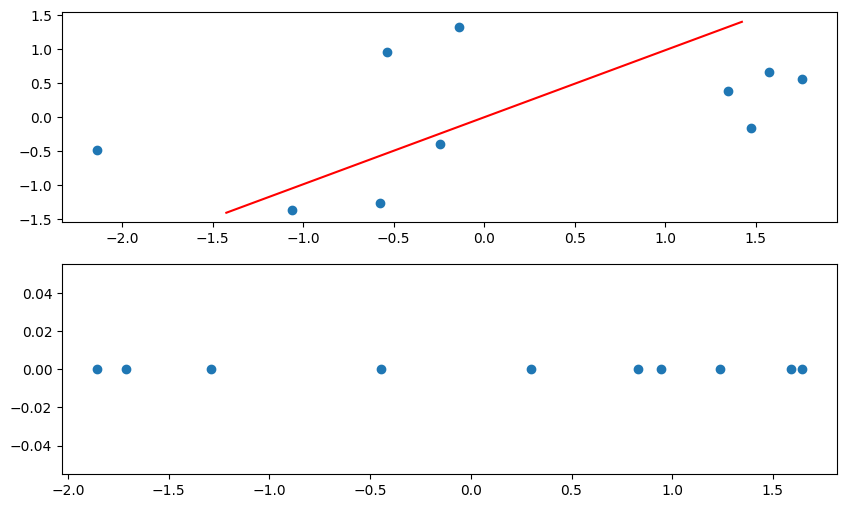

In [ ]:
import matplotlib.pyplot as plt

z, w = pca(a, 1, True)

x = np.linspace(-2, 2, 10)
fig, axs = plt.subplots(2, 1, figsize=(10, 6))
axs[0].scatter(a[:, 0], a[:, 1])
axs[1].scatter(pca(a, 1).reshape(-1), [0]*len(pca(a, 1)))
axs[0].plot((w*x)[0, :], (w*x)[1, :], color="red");